# Group Project 1 "Runoff Prediction" Exercise Sheet

Group 12: Giovanna Limon, Lisa Baron, Eva Herrmann

Welcome to the lovely home of your group project for this years' *Introduction to Advanced Data Analytics* Lecture. This is the place where you find all information regarding your group project, and also the place to work on your group project. You will submit a copy of this file in the end.

## Project description

You are working in groups of max. 3 people. Each group will get assigned, at random, a dataset and a method that was discussed during the lecture. The datasets are coming from the Earth System Sciences, and are both taken from real-world research problems. Your task is to use the two methods you were assigned (one linear and one nonlinear statistical learning method) to fit and predict from the dataset you have been given. For the prediction, you will be given a part of the dataset consisting only of predictors but with target values omitted. For comparing your methods, you will also fit a multiple linear regression model (without any regularisation) to the dataset.

The methods you have been assigned may or may not be suitable one for the dataset. However, the final performance of your code, that is the precision of your prediction, is not important. The key goal is to show that

1. you understand the theoretical background of what a specific method is doing or attempts to do;
2. you are aware of the strengths and limitations of a given method applied to a concrete atmospheric science problem;
3. you are able to correctly apply the method in a training/testing context (e.g., cross-validation, hyperparameter selection, etc.);
4. you are able to interpret the results of your method application to the atmospheric science problem.

Below we have already constructed a framework that helps you through data reading and preparation, gives you space for model fitting and prediction and in the end asks you the questions you need to work on. So you just need to work along the framework and make sure you carefully answer each question, and then you can hand in!

## Method and Data

The pool of methods consists of

| Method | R packages | Function/Help |
| :- | :- | :- |
| Backward subset selection | `leaps` | `?regsubsets` |
| Principal component regression | `pls` | `?pcr` |
| Ridge Regression | `glmnet` | `?glmnet` |
| Lasso Regression | `glmnet` | `?glmnet` |
| Multivariate adaptive regression splines | `earth` | `?earth` |
| Random Forest | `randomForest` | `?randomForest` |
| Boosted Trees | `gbm` | `?gbm` |

NB:
- You will be working with one linear and one non-parametric method from the method pool above. Please find on Moodle which of the methods is assigned to you.
- You can follow the coding style from the exercises to implement your method. Use the help function (e.g. `?regsubsets`) to familiarize yourself with your methods and how to implement them.
- In some cases, you will have to reduce the number of predictors to make it work with resource-demanding methods.


And this is the dataset you'll be working with:

1. **Predicting runoff accross Europe** <br>
This data set contains information on runoff, precipitation and temperature from a long pre-industrial control run of the CESM model. For the purpose of this project, the simulated data is restricted to cover Europe and a randomly selected 30 year time block. The following two versions of the data are available:  <br>

    a. To mimic station data, 15 grid cells were selected at random. At these location data on runoff, precipitation and temperature are available.  <br>
    b. The full gridded data set is only available for precipitation and temperature.  <br>

    The goal of projects working with this data set is to develop a statistical model for runoff using the station data. Following Gudmundsson & Seneviratne (2015)$^1$, runoff $Q_{(s,t)}$ at spatial location $s$ and time step $t$ can be modelled as a function of precipitation, $P_{(s,t)}$ , and temperature $T_{(s,t)}$, such that
    
    $Q_{(s,t)}=f(\tau_\lambda (P_{(s,t)} ), \tau_\lambda (T_{(s,t)} ))$.
    
    The embedding operator $\tau_\lambda (X_{(s,t)} )=[X_{(s,t)},X_{(s,t-1)},…,X_{(s,t-λ)}]$ gives access to the past $\lambda$ time steps. You will train such a model using the station data. The trained model will then be used to infer runoff across the entire spatial domain using gridded precipitation and temperature as predictors.
    
    For a successful application, you will need to find the right parameters for the machine learning model $f$ (the exact method is specified for each project) as well as a good value for the embedding parameter $\lambda$. Select and argue for an approach that helps you to ensure that the chosen model parameters do not over-fit the training data.
    
    $^1$ Gudmundsson, L. and S. I. Seneviratne (2015). "Towards observation-based gridded runoff estimates for Europe." Hydrology and Earth System Sciences 19(6): 2859-2879.

## Help

Please use our moodle forum if you need help. For help on the specific methods or implementation choices, check the specific exercises (all methods have been part of the exercises), or use the R help (e.g., `?randomForest`).

## IMPORTANT: A note on parallel working on a shared resource

Please note that you will have to find a strategy to work on a shared resource. Each of you can follow the advice on Moodle and copy the group project folder in your personal directory. In this case, only the owner can access the data and notebook.
You can, however, use UNIX commands to give everyone access. The command is "chmod -R 777 group_project_folder/". In this case, all of your group members can work in one member's folder, however it is important that **you don't work on it at the same time, and that you make regular backup copies**. Make sure to talk to each other before opening the shared notebook in your hub. Disregarding this advice might lead to loss of data!

All groups are sharing the same server resources. Please be considerate and don't do very expensive analysis. It is ok to use a less precise, less expensive model in your final solution. It is what scientists do all the time. If you need to do that, make sure to discuss this decisions in the evaluation section.

## Preprocessing Project 1: Prediction of runoff across Europe

Below you will find the code that loads and preprocesses your data. Select the dataset you have been assigned to. If you have executed the code, you will end up with data in a tabular manner (rows: datapoints, columns: variables = features). Now it's your turn! Define the predictand and the predictor table. We have already done some feature engineering, i.e. added some features to the table that we think might be valuable for the prediction. However, you can choose how many features (one, some or all) for your model as you like. We suggest you play around a bit with it to understand what your model is doing.

Load libraries.

In [ ]:
require(maps)
require(fields)

Loading required package: maps

Loading required package: fields

Loading required package: spam

Spam version 2.11-3 (2026-01-05) is loaded.
Type 'help( Spam)' or 'demo( spam)' for a short introduction 
and overview of this package.
Help for individual functions is also obtained by adding the
suffix '.spam' to the function name, e.g. 'help( chol.spam)'.


Attaching package: ‘spam’


The following objects are masked from ‘package:base’:

    backsolve, forwardsolve


Loading required package: viridisLite

Loading required package: RColorBrewer


Try help(fields) to get started.



Load and plot pseudo station data.

In [ ]:
## Load RDS files
#RDS Files sind einfach spezielle R Dateitypen um einzelne Objekte (Tabelle zB) abzuspeichern und exakt wieder darzustellen.
runoff.station <- readRDS("data_Project1/RUNOFF_station.rds")
precip.station <- readRDS("data_Project1/PRECIP_station.rds")
temp.station   <- readRDS("data_Project1/TEMP_station.rds")

## inspect data structure
str(runoff.station) ## you can do the same for the other variables

List of 4
 $ data  : num [1:360, 1:15] 8.20e-06 1.51e-05 4.43e-05 3.36e-05 2.49e-05 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr [1:15] "Station.1" "Station.2" "Station.3" "Station.4" ...
 $ latlon:'data.frame':	15 obs. of  3 variables:
  ..$ Station.id: chr [1:15] "Station.1" "Station.2" "Station.3" "Station.4" ...
  ..$ lon       : num [1:15] 7.5 -5 2.5 15 42.5 45 20 2.5 -2.5 -5 ...
  ..$ lat       : num [1:15] 46.4 38.8 33.2 40.7 46.4 ...
 $ time  : num [1:360(1d)] 912104 912135 912166 912194 912225 ...
 $ att   :List of 4
  ..$ dat :List of 5
  .. ..$ long_name    : chr "total liquid runoff (does not include QSNWCPICE)"
  .. ..$ units        : chr "mm/s"
  .. ..$ _FillValue   : num 1e+36
  .. ..$ missing_value: num 1e+36
  .. ..$ cell_methods : chr "time: mean"
  ..$ lat :List of 4
  .. ..$ standard_name: chr "latitude"
  .. ..$ long_name    : chr "latitude"
  .. ..$ units        : chr "degrees_north"
  .. ..$ axis         : chr "Y"
  ..$ lon :List of 4
  

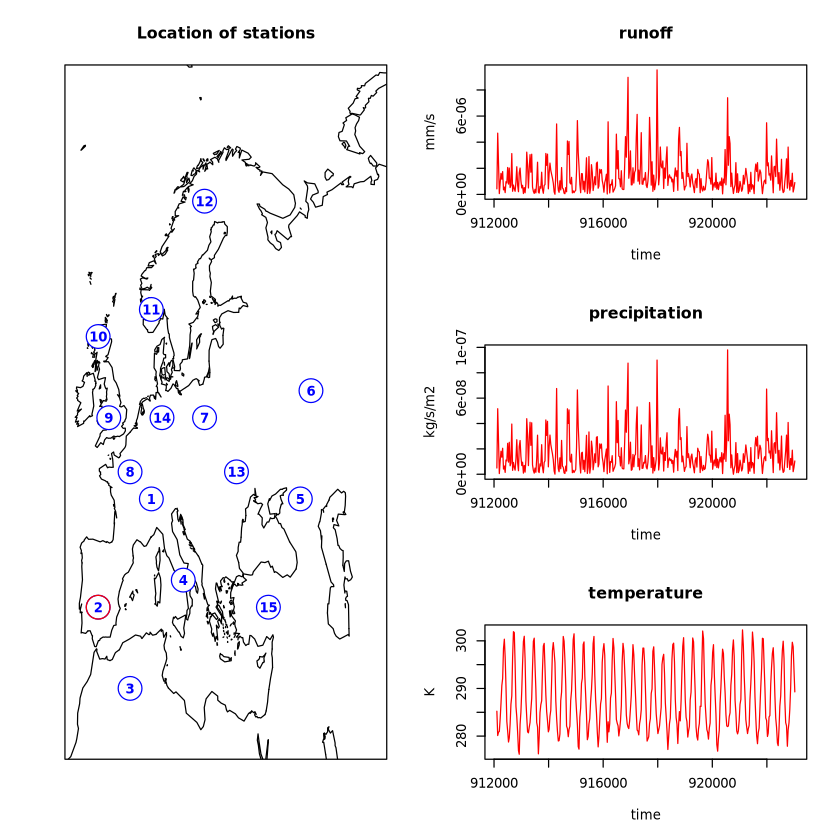

In [ ]:
## Plot some of the data

## setup multi panel plot
ll <- cbind(rep(1,3),2:4)
layout(ll)

plot.new()
plot.window(xlim=c(-10,60),ylim=c(30,75))
map("world",add=TRUE,interior=FALSE)
points(lat~lon,data=runoff.station$latlon,cex=4,pch=21,col="blue",bg="white")
station.number <- gsub("Station.","",runoff.station$latlon$Station.id)
with(runoff.station$latlon,text(lon,lat,labels=station.number,col="blue",font=2))
title(main="Location of stations")
box()

## select one staiton on the map
sel.station <- "Station.2" ## you can choose any other station
points(lat~lon,data=runoff.station$latlon[sel.station,],pch=1,cex=4,col="red")

## plot time series of runoff, precipitation and temperature
with(runoff.station,plot(time,data[,sel.station],t="l",col="red",main="runoff",
                         ylab=att$dat$units))
with(precip.station,plot(time,data[,sel.station],t="l",col="red",main="precipitation",
                         ylab=att$dat$units))
with(temp.station,plot(time,data[,sel.station],t="l",col="red",main="temperature",
                         ylab=att$dat$units))

Load and plot gridded data.

In [ ]:
## load
precip.grid <- readRDS("data_Project1/PRECIP_grid.rds")
temp.grid <- readRDS("data_Project1/TEMP_grid.rds")

## inspect data structure
str(precip.grid) ## you can do the same for the other variables

List of 3
 $ dat  : num [1:29, 1:21, 1:360] 6.29e-10 3.51e-10 5.05e-10 5.57e-10 6.72e-10 ...
 $ coord:List of 3
  ..$ lat : num [1:21(1d)] 31.3 33.2 35.1 36.9 38.8 ...
  ..$ lon : num [1:29(1d)] -10 -7.5 -5 -2.5 0 2.5 5 7.5 10 12.5 ...
  ..$ time: num [1:360(1d)] 912104 912135 912166 912194 912225 ...
 $ att  :List of 4
  ..$ dat :List of 3
  .. ..$ _FillValue   : num -9e+33
  .. ..$ missing_value: num -9e+33
  .. ..$ units        : chr "kg/s/m2"
  ..$ lat :List of 4
  .. ..$ standard_name: chr "latitude"
  .. ..$ long_name    : chr "latitude"
  .. ..$ units        : chr "degrees_north"
  .. ..$ axis         : chr "Y"
  ..$ lon :List of 4
  .. ..$ standard_name: chr "longitude"
  .. ..$ long_name    : chr "longitude"
  .. ..$ units        : chr "degrees_east"
  .. ..$ axis         : chr "X"
  ..$ time:List of 5
  .. ..$ standard_name: chr "time"
  .. ..$ long_name    : chr "time"
  .. ..$ units        : chr "days since 0001-01-01 00:00:00"
  .. ..$ calendar     : chr "365_day"
  .. ..$

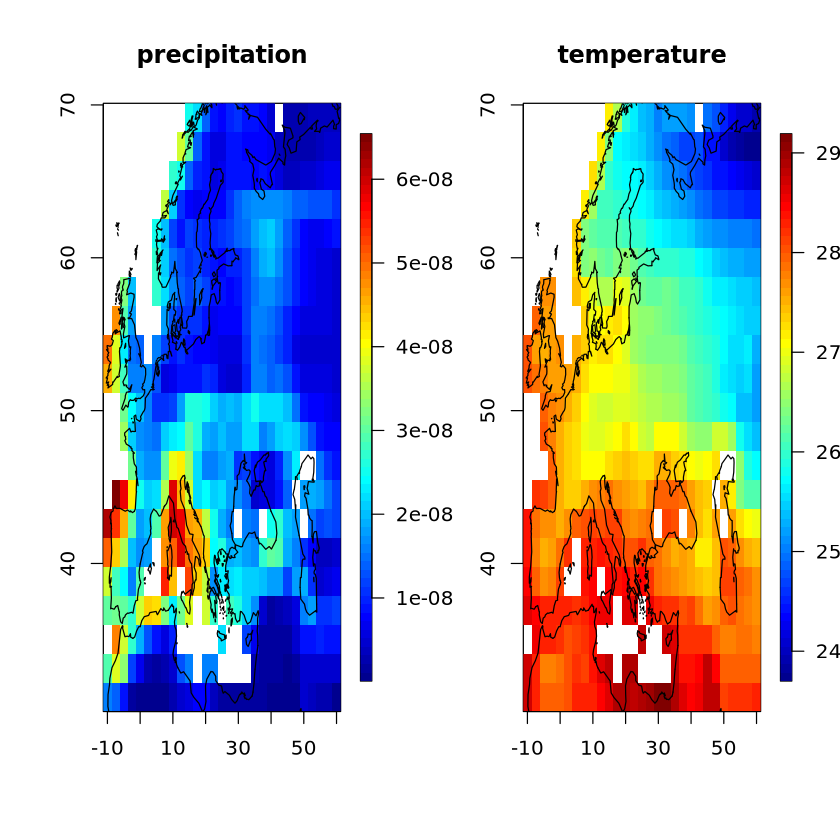

In [ ]:
## Plot some of the data

## select a time step (any integer from 1 to 360)
sel.time.step <- 100

par(mfrow=c(1,2))
with(precip.grid,image.plot(x=coord$lon,y=coord$lat,z=dat[,,sel.time.step],
                            main="precipitation",xlab="",ylab=""))
map("world",add=TRUE,interior=FALSE)
##
with(temp.grid,image.plot(x=coord$lon,y=coord$lat,z=dat[,,sel.time.step],
                            main="temperature",xlab="",ylab=""))
map("world",add=TRUE,interior=FALSE)

In [ ]:
runoff.station$data

Station.1,Station.2,Station.3,Station.4,Station.5,Station.6,Station.7,Station.8,Station.9,Station.10,Station.11,Station.12,Station.13,Station.14,Station.15
8.198748e-06,4.266585e-07,1.682964e-11,1.733966e-06,4.945027e-07,3.756153e-05,4.490835e-06,7.302206e-06,1.199783e-05,5.600215e-05,4.909561e-05,9.929593e-06,2.046241e-06,8.836292e-06,1.523377e-06
1.508317e-05,4.691453e-06,5.132587e-10,5.672301e-06,4.474761e-07,2.733694e-05,4.208920e-06,7.622542e-06,6.442328e-06,5.573326e-05,7.070916e-05,7.895137e-06,3.187304e-06,8.836582e-06,2.495599e-06
4.431113e-05,2.274431e-06,8.435886e-11,8.644768e-07,8.665361e-07,1.062607e-05,8.634501e-06,1.644966e-05,1.115468e-05,5.249501e-05,4.533029e-05,6.231053e-06,2.884418e-06,1.365562e-05,2.443128e-06
3.359967e-05,6.284289e-08,7.942170e-10,1.547597e-06,3.901712e-07,5.391831e-06,6.708375e-06,2.551794e-05,9.899960e-06,7.205838e-05,7.507947e-05,5.188422e-06,1.971411e-06,1.540367e-05,2.634803e-06
2.494224e-05,8.883919e-07,1.991586e-10,2.029359e-06,2.930306e-07,5.980256e-06,6.264971e-06,2.101801e-05,1.207350e-05,6.205161e-05,4.767560e-05,4.427947e-06,1.201577e-06,1.398745e-05,4.966006e-06
1.140942e-05,1.611231e-06,3.895653e-09,2.463539e-06,2.988174e-07,3.114326e-05,5.601475e-06,1.168787e-05,1.156715e-05,2.927462e-05,3.421735e-05,3.346421e-05,2.036938e-06,1.351629e-05,1.996214e-06
9.666182e-06,1.165945e-06,2.318366e-09,2.065953e-06,7.297442e-07,2.203013e-05,7.424892e-06,9.718954e-06,8.619000e-06,9.426995e-06,2.743769e-05,2.143506e-05,2.545390e-06,1.336941e-05,3.011070e-06
1.002820e-05,1.746179e-06,2.748618e-10,5.568795e-07,2.646667e-07,1.243943e-05,8.634305e-06,1.155480e-05,1.020461e-05,8.058907e-06,1.434045e-05,2.033616e-05,4.075515e-06,1.550067e-05,1.106112e-06
4.549703e-06,3.518927e-07,7.182720e-11,7.629045e-08,2.362758e-07,7.887437e-06,9.389554e-06,7.496835e-06,7.220674e-06,9.917888e-06,1.178801e-05,1.349890e-05,2.414959e-06,1.272863e-05,2.572418e-07
2.470849e-06,5.614584e-07,1.596705e-09,1.452357e-07,1.380900e-08,4.574244e-06,8.828158e-06,4.262098e-06,4.569276e-06,1.181197e-05,1.181804e-05,1.457258e-05,1.705599e-06,8.157424e-06,2.376864e-07


For estimating runoff as a function of precipitation and temperature
we need to account for present and past information of these variables.
for doing so, precipitaiton and temperature are embedded into a
time-lagged matrix. Note: for fitting a regression model at more than one location,
the embedded predictors from all locations are stacked on top
of each other in one single table. Trying on artificial data

In [ ]:
embed.predictors <- function(x,lambda,var.name){
### function for embedding predictor
###
### x: a vector or a column matrix
### lambda: embedding parameter
### var.name: variable name, used to construct column names of the output
    lambda <- lambda + 1
    if(is.vector(x)){
        x.emb <- embed(x,dimension=lambda)
    } else {
        x <- t(x)
        xf <- seq(nrow(x))
        x.split <- split(x,f=xf)
        names(x.split) <- rownames(x)
        x.emb <- lapply(x.split,embed,dimension=lambda)
        x.emb <- do.call(rbind,x.emb)
    }
    nms <- paste0(var.name,0:(lambda-1))
    colnames(x.emb) <- nms
    return(x.emb)
}

In [ ]:
## artificial data for illustration
embed.predictors(1:10,lambda=2,var.name="x")
embed.predictors(cbind(1:10,11:20),lambda=2,var.name="x")

x0,x1,x2
3,2,1
4,3,2
5,4,3
6,5,4
7,6,5
8,7,6
9,8,7
10,9,8


x0,x1,x2
3,2,1
4,3,2
5,4,3
6,5,4
7,6,5
8,7,6
9,8,7
10,9,8
13,12,11
14,13,12


In [ ]:
## application to one single station (try several lambda values!)
precip.one.station.emb <- embed.predictors(precip.station$data[,"Station.1"],lambda=2,var.name="PP")

## inspect
str(precip.one.station.emb)

 num [1:358, 1:3] 4.62e-08 2.16e-08 2.25e-08 1.55e-08 3.42e-08 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:3] "PP0" "PP1" "PP2"


In [ ]:

## application to one all stations (try several lambda values!)
precip.all.stations.emb <- embed.predictors(precip.station$data,lambda=2,var.name="PP")

## inspect
str(precip.all.stations.emb)

 num [1:5370, 1:3] 4.62e-08 2.16e-08 2.25e-08 1.55e-08 3.42e-08 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:3] "PP0" "PP1" "PP2"


Due to the embedding the effective number of time steps that can be used for
modelling is reduced therefore the first lambda time steps need to be discarded. Note: for fitting a regression model at more than one location,
the truncated target time series are stacked on top of
each other in one large table.

In [ ]:
truncate.target <- function(x,lambda){
### function for truncating the target variable
###
### x: a vector or a column matrix
### lambda: embedding parameter
    if(is.vector(x)){
        x.trunc <- x[-(1:(lambda))]
    } else {
        x <- t(x)
        xf <- seq(nrow(x))
        x.split <- split(x,f=xf)
        names(x.split) <- rownames(x)
        x.trunc <- lapply(x.split,"[",i=-(1:(lambda)))
        x.trunc <- do.call(c,x.trunc)
    }
    return(x.trunc)
}

In [ ]:
## artificial data for illustration
truncate.target(1:10,lambda=2)
truncate.target(cbind(1:10,11:20),lambda=2)

[1]  3  4  5  6  7  8  9 10

[1]  3  4  5  6  7  8  9 10 13 14 15 16 17 18 19 20

In [ ]:
## application to one single station
runoff.one.station.trunc <- truncate.target(runoff.station$data[,"Station.1"],lambda=2)

## inspect
str(runoff.one.station.trunc)

 num [1:358] 4.43e-05 3.36e-05 2.49e-05 1.14e-05 9.67e-06 ...


In [ ]:
## application to one all stations
runoff.all.stations.trunc <- truncate.target(runoff.station$data,lambda=2)

## inspect
str(runoff.all.stations.trunc)

 Named num [1:5370] 4.43e-05 3.36e-05 2.49e-05 1.14e-05 9.67e-06 ...
 - attr(*, "names")= chr [1:5370] "Station.11" "Station.12" "Station.13" "Station.14" ...


## Apply standard linear regression

Example work-flow with linear regression to get you started

In [ ]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 1 -- Embed the predictor time series and combine data into one table
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## select lambda
sel.lambda <- 11 ## this is likely not an optimal value!

## prepare data from all stations
## 1. embed precipitation and temperature
## 2. truncate runoff
all.stations.for.model.training <- data.frame(
    QQ=truncate.target(runoff.station$data,lambda=sel.lambda), #column 1
    embed.predictors(precip.station$data,lambda=sel.lambda,var.name="PP"), # column 2
    embed.predictors(temp.station$data,lambda=sel.lambda,var.name="TT") # column 3
)

## inspect
str(all.stations.for.model.training)

'data.frame':	5235 obs. of  25 variables:
 $ QQ  : num  9.28e-07 5.47e-06 4.56e-06 5.99e-06 1.11e-05 ...
 $ PP0 : num  4.35e-09 3.98e-08 2.25e-08 2.10e-08 3.74e-08 ...
 $ PP1 : num  2.60e-08 4.35e-09 3.98e-08 2.25e-08 2.10e-08 ...
 $ PP2 : num  9.05e-09 2.60e-08 4.35e-09 3.98e-08 2.25e-08 ...
 $ PP3 : num  1.64e-08 9.05e-09 2.60e-08 4.35e-09 3.98e-08 ...
 $ PP4 : num  4.70e-08 1.64e-08 9.05e-09 2.60e-08 4.35e-09 ...
 $ PP5 : num  3.42e-08 4.70e-08 1.64e-08 9.05e-09 2.60e-08 ...
 $ PP6 : num  1.55e-08 3.42e-08 4.70e-08 1.64e-08 9.05e-09 ...
 $ PP7 : num  2.25e-08 1.55e-08 3.42e-08 4.70e-08 1.64e-08 ...
 $ PP8 : num  2.16e-08 2.25e-08 1.55e-08 3.42e-08 4.70e-08 ...
 $ PP9 : num  4.62e-08 2.16e-08 2.25e-08 1.55e-08 3.42e-08 ...
 $ PP10: num  5.14e-08 4.62e-08 2.16e-08 2.25e-08 1.55e-08 ...
 $ PP11: num  4.55e-08 5.14e-08 4.62e-08 2.16e-08 2.25e-08 ...
 $ TT0 : num  281 276 269 271 273 ...
 $ TT1 : num  287 281 276 269 271 ...
 $ TT2 : num  289 287 281 276 269 ...
 $ TT3 : num  288 289 287

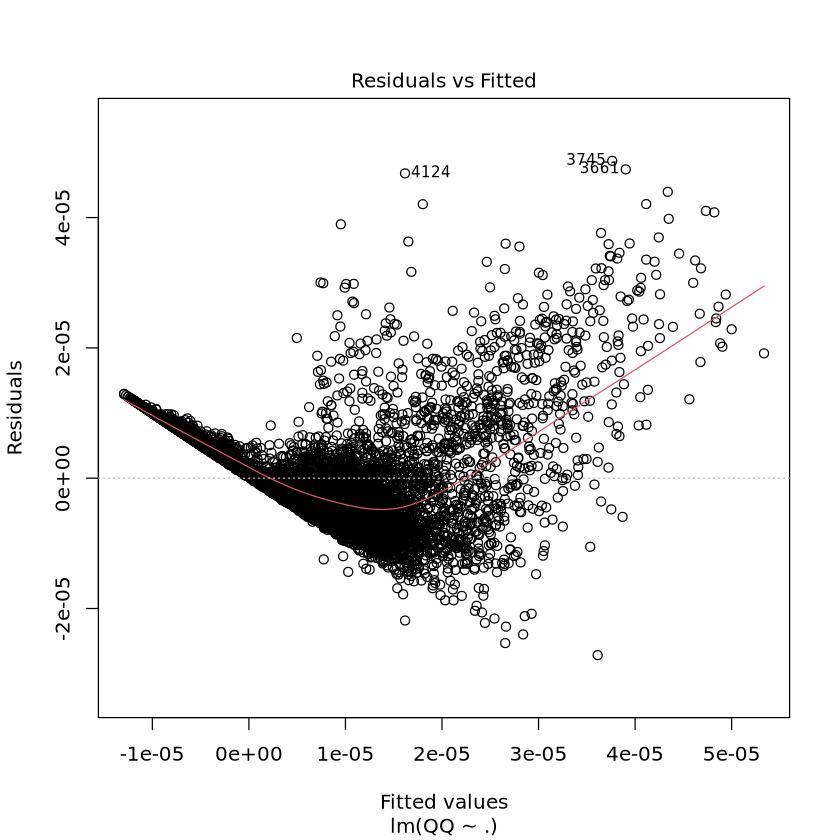

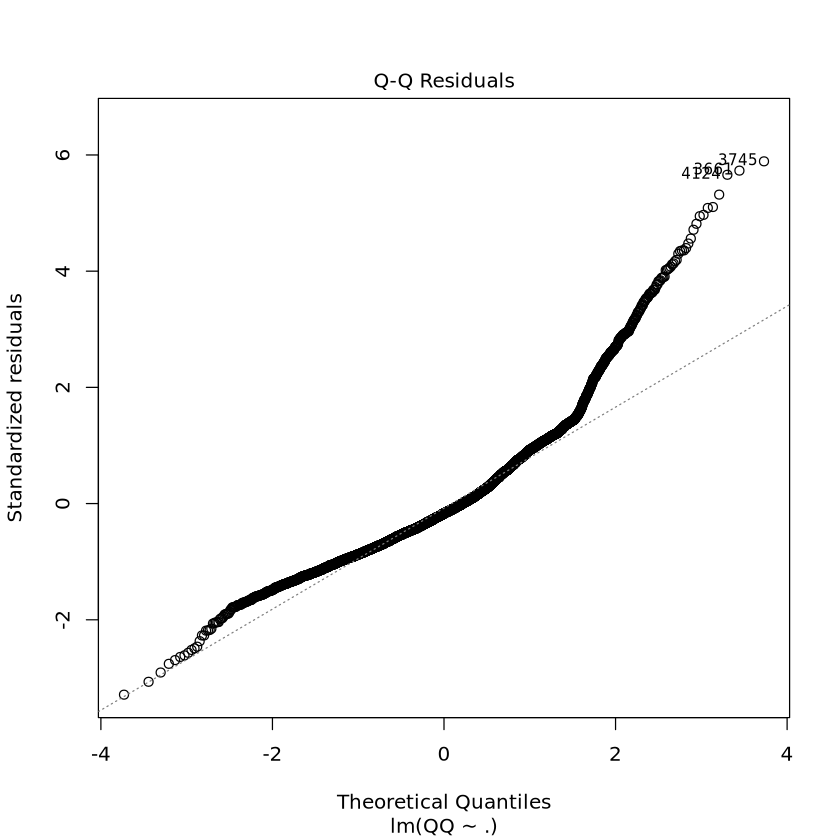

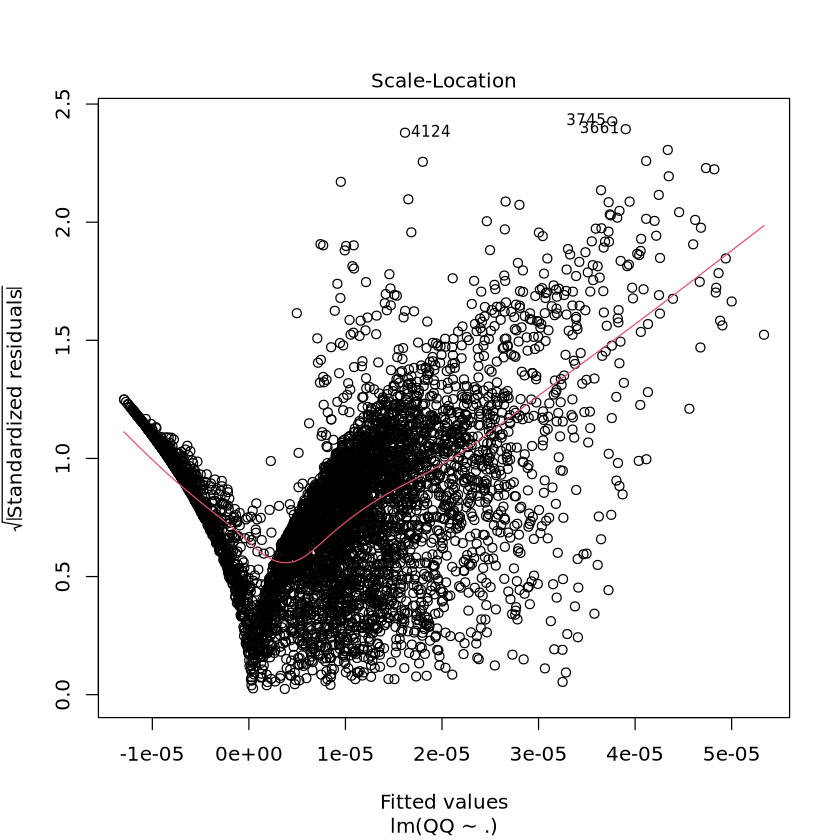

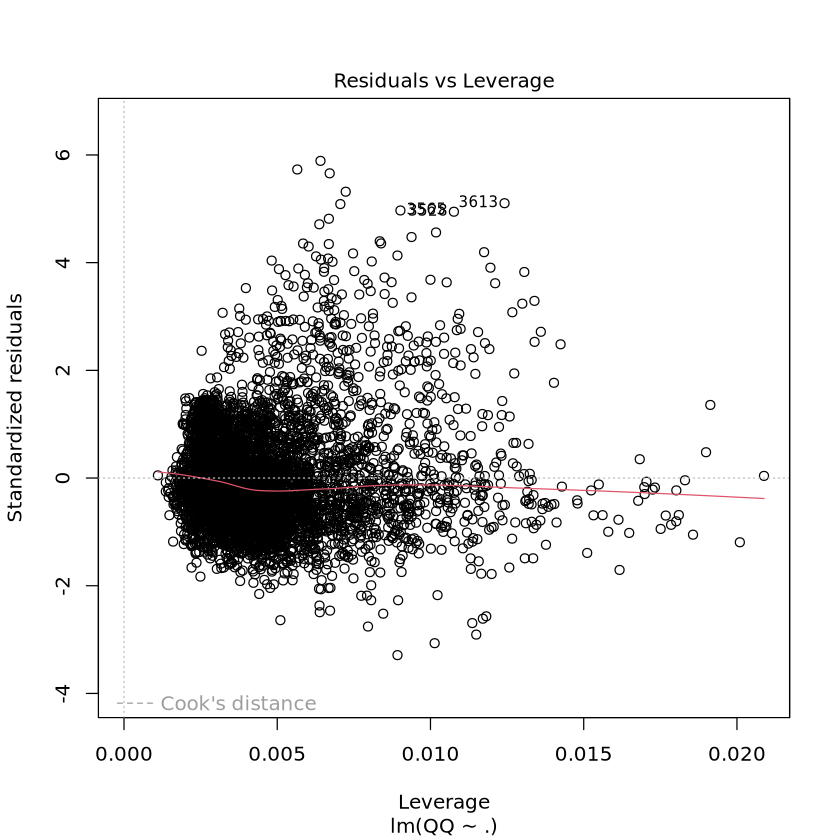

In [ ]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 2 -- fit a simple linear regression model
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## Note:
##
## The notation 'QQ~.,data=...' used below indicates that the
## variable named 'QQ' (runoff) should be modelled as a function
## of all other variables in the data.frame 'data' (i.e. embedded precipitation
## and temperature).
##
## many (but not all) regression tools in R support this 'formula'
## notation.

all.stations.lm <- lm(QQ~.,data=all.stations.for.model.training)
plot(all.stations.lm)

## Apply Model P1: Prediction of runoff accross Europe

In [ ]:
library(glmnet)
# to use lasso with glmnet: alpha is 1

Loading required package: Matrix


Attaching package: ‘Matrix’


The following object is masked from ‘package:spam’:

    det


Loaded glmnet 4.1-10



In [ ]:
# make sure all stations have the same number of rows & no NaNs (for splitting)
colSums(!is.na(runoff.station$data))

Station.1  Station.2  Station.3  Station.4  Station.5  Station.6  Station.7 
       360        360        360        360        360        360        360 
 Station.8  Station.9 Station.10 Station.11 Station.12 Station.13 Station.14 
       360        360        360        360        360        360        360 
Station.15 
       360

In [ ]:
# get range of values per station
# for station 10: negative values?!
apply(runoff.station$data, 2, range, na.rm = TRUE)

Station.1,Station.2,Station.3,Station.4,Station.5,Station.6,Station.7,Station.8,Station.9,Station.10,Station.11,Station.12,Station.13,Station.14,Station.15
9.275661e-07,1.254366e-08,8.464314e-20,1.133358e-08,3.906982e-09,2.568568e-07,3.054778e-06,1.261443e-06,1.254418e-06,-5.662486e-06,4.670478e-06,2.983671e-06,1.958080e-07,4.016214e-06,6.558469e-08
5.640578e-05,9.535711e-06,9.410279e-09,7.356267e-06,2.620514e-06,3.756153e-05,1.998674e-05,5.396579e-05,4.891331e-05,8.329401e-05,8.900639e-05,6.295351e-05,8.475147e-06,1.981271e-05,9.444581e-06


### Issues
Letting the lasso model run using the actual data as input is problematic, as the runoff ranges of the stations are quite different. In that way, for rmse.val / sd(y.val) the lasso model produces a huge validation error of ~1.2315. This means, it performs worse than just guessing the mean. The train error is <0.6, meaning the model itself isn't the issue, the fit just doesn't translate well to unseen data.
To account for the different ranges, one possible solution could be to normalize the data using per station mean/std before applying the model. Then a new issue for the prediction would occur: If normalizing per station would be done, the model would learn in z-score space and also produce outputs in z-score space. Therefore it can not be done here.

In [ ]:
# prepare split data: find number od stations & rows
n.stations <- ncol(runoff.station$data) # before truncating: how stations are there?
rows.per.station <- nrow(runoff.station$data) - sel.lambda  # after truncating (- sel.lambda): how many observations per station?

station.id <- rep(1:n.stations, each = rows.per.station) # know where in the new table one stations ends and a new one starts

# split data: train & validation
set.seed(42) # make split reproducible
train.stations <- sample(1:n.stations, size = round(0.7 * n.stations)) # choose around 70% for train (but: station as whole unit)

train.idx <- which(station.id %in% train.stations) # index for training data
val.idx   <- which(station.id %in% setdiff(1:n.stations, train.stations)) # all stations that are not train

train.data <- all.stations.for.model.training[train.idx, ] # actual training data
val.data   <- all.stations.for.model.training[val.idx, ]

In [ ]:
# train the model:
# x and y for training
x <-as.matrix(train.data[, -1]) # all rows & all columns except 1 which is QQ
y <- train.data$QQ # select QQ which should be predicted

# fit lasso with cross-validation
cv.lasso <- cv.glmnet( # default: 10-fold with 9 train, 1 test
  x = x,
  y = y,
  alpha = 1, # for lasso
  standardize = TRUE
)

# choose best penalty lambda
best.lambda <- cv.lasso$lambda.min # lambda, where cv error is minimal

# final lasso model --> same as we did in the exercise called: all.stations.lasso
all.stations.lasso <- glmnet(
  x = x,
  y = y,
  alpha = 1,
  lambda = best.lambda,
  standardize = TRUE
)

coef(all.stations.lasso)

25 x 1 sparse Matrix of class "dgCMatrix"
                       s0
(Intercept)  1.651608e-04
PP0          2.787982e+02
PP1          2.041094e+02
PP2          1.773108e+02
PP3          1.270557e+02
PP4          7.674598e+01
PP5          2.617830e+01
PP6         -1.053026e+01
PP7         -2.548651e+01
PP8         -1.788214e+01
PP9          9.978807e+00
PP10         2.193354e+00
PP11         3.201802e+00
TT0          8.929720e-08
TT1         -7.586380e-08
TT2         -2.125164e-08
TT3         -7.851049e-08
TT4         -1.445702e-07
TT5         -6.380565e-08
TT6          .           
TT7          .           
TT8         -2.819972e-08
TT9         -1.063397e-07
TT10        -3.803431e-08
TT11        -1.525397e-07

In [ ]:
# MODEL VALIDATION (on my validation split)
x.val <- as.matrix(val.data[, -1])
y.val <- val.data$QQ

pred.val <- predict(all.stations.lasso, newx = x.val, s = best.lambda) # actual prediction

# get the validation error
rmse.val <- sqrt(mean((y.val - pred.val)^2))
rmse.val

#get validation R²
r2.val <- 1 - sum((y.val - pred.val)^2) / sum((y.val - mean(y.val))^2)
r2.val

# understand the meaning of RMSE (small value, but how small compared to y.val values?)
cat("mean val:", mean(y.val), "\n")
cat("std val:", sd(y.val), "\n")
rmse.val / sd(y.val)

[1] 8.060774e-06

[1] -0.9002062

mean val: 6.444193e-06 
std val: 5.849259e-06 


[1] 1.378085

In [ ]:
# compare validation to training error, to see whether model is bad or overfitting is happening
pred.train <- predict(all.stations.lasso, newx = x, s = best.lambda)
rmse.train <- sqrt(mean((y - pred.train)^2))
rmse.train / sd(y)

[1] 0.5699032

In [ ]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 3 -- Predict all stations
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## Note:
##
## for prediction the function 'predict(object=fitted.model,newdata=some.new.data)'
## is used. This workflow is supported by many, but not all, regression
## models in R. The data.frame 'some.new.data' needs to contain
## columns that have the same names as those variables in the data.frame that
## was used for model training (except the target variable)

## create place holder for predictions
all.station.runoff.pred <- runoff.station$data
all.station.runoff.pred[] <- NA

## iterate over stations
for(st in colnames(precip.station$data)){
    ## prepare predictor matrix --> using both PP & TT to predict QQ
    emb.predictors <- data.frame(
        embed.predictors(precip.station$data[,st],lambda=sel.lambda,var.name="PP"),
        embed.predictors(temp.station$data[,st],lambda=sel.lambda,var.name="TT")
    )
    ## do the prediction
    ## Note: the first (sel.lambda) values are left blank as a result of the embedding
    x.new <- as.matrix(emb.predictors) # use station PP & TT values for prediciton of QQ
    all.station.runoff.pred[-(1:sel.lambda),st] <- predict(all.stations.lasso, newx = x.new, s = best.lambda) # actual prediction happens here & list is populated
    # for sel.lambda=3, three rows of data are lost (not enough past values)
    #newx: makes sure you know this is for prediction
}
# lasso penalty is already optimized by cv BUT: lag isn't

In [ ]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 4 -- Evaluate the performance at the stations
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

##
## overall performance
##

## mean squared error
mse.grid <- mean((runoff.station$data - all.station.runoff.pred)^2,na.rm=TRUE) # last part ignores missing values from embedding; observed vs. predicted values
cat("MSE:", mse.grid, "\n")
rmse.grid <- sqrt(mse.grid)
cat("interpretable value:", rmse.grid / sd(runoff.station$data, na.rm = TRUE), "\n")

## R-squared
cat("R²:", cor(as.numeric(runoff.station$data),as.numeric(all.station.runoff.pred),use="complete.obs")^2)

##
## performance at individual staitions
##

## mean squared error
sapply(colnames(runoff.station$data),function(i){
    mean((runoff.station$data[,i] - all.station.runoff.pred[,i])^2,na.rm=TRUE)
})

## R-squared
sapply(colnames(runoff.station$data),function(i){
    R2 <- cor(as.numeric(runoff.station$data[,i]),as.numeric(all.station.runoff.pred[,i]),
              use="complete.obs")^2
})

MSE: 7.38325e-11 
interpretable value: 0.6425537 
R²: 0.6054544

Station.1    Station.2    Station.3    Station.4    Station.5    Station.6 
7.376616e-11 4.867376e-11 1.825277e-10 4.766102e-11 1.137063e-11 6.211483e-11 
   Station.7    Station.8    Station.9   Station.10   Station.11   Station.12 
1.715622e-11 5.108907e-11 4.989376e-11 1.633326e-10 1.936234e-10 1.039077e-10 
  Station.13   Station.14   Station.15 
4.443962e-11 1.199261e-11 4.593840e-11

Station.1  Station.2  Station.3  Station.4  Station.5  Station.6  Station.7 
0.68883100 0.44666318 0.34257973 0.41946265 0.24304007 0.01359985 0.08358422 
 Station.8  Station.9 Station.10 Station.11 Station.12 Station.13 Station.14 
0.55308295 0.52721046 0.76334136 0.69374149 0.16041499 0.27405265 0.29576834 
Station.15 
0.46696728

### Evaluation of overall performance (stations)

> sel.lambda = 4: R²~0.60
> 12: R²= 0.6058839
> 15: R²: 0.6068816

In [ ]:
precip.grid

$dat
, , 1

              [,1]         [,2]         [,3]         [,4]         [,5]
 [1,] 6.286117e-10 9.381739e-10           NA 3.994478e-09 9.043938e-09
 [2,] 3.505021e-10 8.940534e-10 8.820067e-10 2.084025e-09 6.376449e-09
 [3,] 5.048886e-10 7.292090e-10 3.210675e-10 1.134774e-09 4.921580e-09
 [4,] 5.574821e-10 3.840517e-10 2.513424e-10 4.493514e-10 7.033222e-10
 [5,] 6.724674e-10 3.738978e-10 2.529895e-10 1.341751e-09 1.088226e-09
 [6,] 5.707672e-10 2.907514e-10 2.738922e-10 2.344511e-09           NA
 [7,] 5.104367e-10 2.264605e-10 2.791279e-10 2.414578e-09           NA
 [8,] 3.067415e-10 2.522376e-10 2.726243e-10 2.488922e-09 7.557936e-09
 [9,] 1.691702e-10 1.352024e-09 1.154683e-09 1.708053e-09 7.743236e-09
[10,] 4.821488e-10 4.061968e-09           NA 3.215285e-09           NA
[11,] 1.943642e-09 6.229989e-09           NA 4.767757e-09 1.211702e-08
[12,] 6.863679e-09           NA           NA           NA 1.344253e-08
[13,] 1.168295e-08 1.649304e-08           NA 1.292361e-08 1.961562e-08
[14,] 4.660528e-09 1.412854e-08           NA 1.506321e-08 1.221759e-08
[15,] 5.206255e-09           NA 1.970813e-08           NA 2.365283e-08
[16,] 7.032665e-09           NA           NA 3.076590e-08 2.503941e-08
[17,] 9.241060e-09           NA           NA 2.571175e-08 2.037082e-08
[18,] 9.158178e-09           NA 2.593615e-08 1.293364e-08 1.311991e-08
[19,] 5.290841e-09 2.596945e-08 2.937920e-08 1.776080e-08 1.235783e-08
[20,] 1.304689e-09 6.887903e-09 8.571170e-09 1.307692e-08 1.673936e-08
[21,] 2.243127e-10 8.482758e-10 3.909205e-09 1.090371e-08 2.081139e-08
[22,] 9.496333e-11 1.192473e-10 1.738641e-09 1.357114e-08 2.086817e-08
[23,] 8.836629e-11 8.664778e-11 3.247315e-10 8.576506e-09 9.707751e-09
[24,] 2.290045e-10 1.398774e-10 1.634142e-10 8.832193e-10 3.271774e-09
[25,] 6.431979e-09 5.138513e-10 3.494569e-10 9.354318e-09 1.037898e-08
[26,] 5.366718e-09 1.822501e-09 1.557349e-09 1.536125e-08 1.149980e-08
[27,] 3.114265e-09 3.056526e-09 1.579356e-09 4.421283e-09 2.366277e-09
[28,] 1.856225e-09 3.477431e-09 2.274334e-09 2.069083e-09 9.906889e-10
[29,] 1.221091e-09 1.732099e-09 3.008121e-09 1.463157e-09 9.192502e-10
              [,6]         [,7]         [,8]         [,9]        [,10]
 [1,] 2.514487e-08 4.685536e-08           NA           NA           NA
 [2,] 2.349537e-08 4.202480e-08 6.768620e-08           NA           NA
 [3,] 1.219549e-08 2.037811e-08 6.444884e-08           NA 7.723774e-08
 [4,] 1.611433e-09 8.986064e-09 6.373493e-08 8.665386e-08 6.932802e-08
 [5,] 1.380660e-09 5.286005e-09 4.639576e-08 6.221936e-08 5.954033e-08
 [6,] 2.408560e-09 7.922111e-09 3.142505e-08 4.599800e-08 5.203625e-08
 [7,]           NA 1.448771e-08 2.300165e-08 4.178415e-08 5.267889e-08
 [8,] 1.077951e-08 1.786217e-08 2.438622e-08 4.547489e-08 6.697819e-08
 [9,] 1.363725e-08 2.309417e-08 2.759875e-08 3.038656e-08 3.355027e-08
[10,] 1.662680e-08 2.020721e-08 2.432874e-08 1.976565e-08 1.732109e-08
[11,] 1.587109e-08 2.776383e-08 3.438548e-08 1.803679e-08 1.154887e-08
[12,] 2.422287e-08 3.901901e-08 3.894884e-08 2.249975e-08 9.955219e-09
[13,] 2.452027e-08 3.197782e-08 4.024051e-08 2.775251e-08 1.562421e-08
[14,] 1.302091e-08 2.056910e-08 2.643903e-08 3.183107e-08 2.633143e-08
[15,] 2.441836e-08 1.886995e-08 1.911800e-08 2.500979e-08 2.978599e-08
[16,] 2.666759e-08 1.738595e-08 1.177594e-08 1.653322e-08 1.972765e-08
[17,] 2.728495e-08           NA 2.195167e-08 1.874522e-08 1.835110e-08
[18,] 2.250819e-08 2.718028e-08 3.695705e-08 2.988003e-08 2.295434e-08
[19,] 1.913038e-08 2.800908e-08 3.483688e-08 2.719916e-08 2.451093e-08
[20,] 2.342892e-08           NA 3.802666e-08 2.827872e-08 2.472722e-08
[21,] 2.621583e-08 4.164218e-08 3.600834e-08 2.471411e-08 2.421919e-08
[22,] 2.294528e-08 2.962665e-08 2.398296e-08 1.894452e-08 2.390466e-08
[23,] 1.132017e-08 1.121381e-08 1.063719e-08 1.598279e-08 2.258238e-08
[24,] 2.665151e-09 6.576033e-09           NA 1.795713e-08 2.784656e-08
[25,] 7.881117e-09           NA 1.958465e-08           NA 3.485227e-08
[26,] 9.8170

In [ ]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 5 -- Apply the final model to the full grid!!
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## place holder for predicitons
runoff.grid.pred <- precip.grid$dat
runoff.grid.pred[] <- NA

for(ii in 1:dim(precip.grid$dat)[1]){
    for(jj in 1:dim(precip.grid$dat)[2]){
        emb.predictors <- data.frame(
            embed.predictors(precip.grid$dat[ii,jj,],lambda=sel.lambda,var.name="PP"), # now gridded data used as predictors
            embed.predictors(temp.grid$dat[ii,jj,],lambda=sel.lambda,var.name="TT")
        )
        ## do the prediction
        datagrid <- as.matrix(emb.predictors)
        ## Note: the first (sel.lambda) values are left blank as a result of the embedding
        runoff.grid.pred[ii,jj,-(1:sel.lambda)] <- predict(all.stations.lasso,newx=datagrid, s=best.lambda)
    }
}

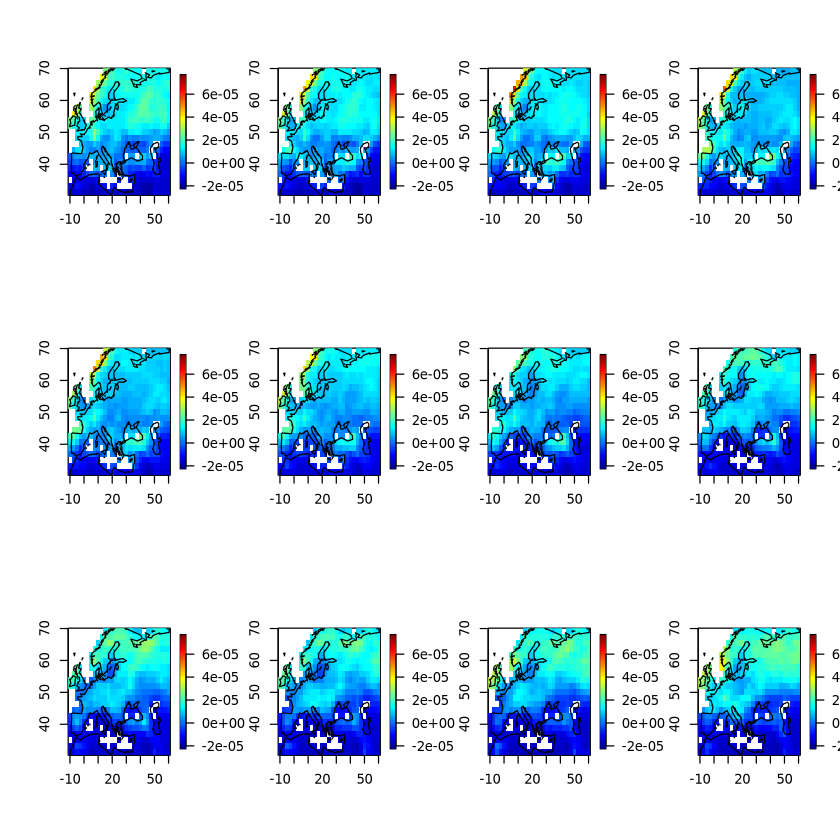

In [ ]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 6 -- Inspect and save the data...
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## plot some time slices (over 12 months)
runoff.range <- range(runoff.grid.pred,na.rm=TRUE) # for zlim (colorscale & values)
par(mfrow=c(3,4)) # plot layout with 3 rows & 4 columns
for(i in 13:24){ # select one year to fill the layout
    with(precip.grid,image.plot(x=coord$lon,y=coord$lat, # map coordinates; precip.grid for relevant metadata
                                z=runoff.grid.pred[,,i],zlim=runoff.range,ann=FALSE))    # grid.pred: pred. QQ values are plotted; ann: no lables
    map("world",add=TRUE,interior=FALSE) # puts background map
}

## save the data (use this as a template for saving the data for submission)
## use following convention for the file name:
## "runoff_*method*_group_*X*.rds"
## --> replace *method* with an acronym of the method/name of the funciton
## used for model training.
## --> replace *X* with your group number
saveRDS(runoff.grid.pred,file="runoff_lasso_group_12.rds")

In [ ]:
# we don't have any values to compare predictions to.
# compare grid predictions to runoff station measurements closeby
station.lat <- runoff.station$latlon$lat
station.lon <- runoff.station$latlon$lon

grid.lat <- precip.grid$coord$lat
grid.lon <- precip.grid$coord$lon

## for each station, find nearest grid indices
nearest.ii <- sapply(station.lat, function(l) which.min(abs(grid.lat - l)))
nearest.jj <- sapply(station.lon, function(l) which.min(abs(grid.lon - l)))

## extract grid-based predictions at station locations, compare to true station runoff
rmse.per.station <- numeric(length(station.lat))
r2.per.station   <- numeric(length(station.lat))

for(k in seq_along(station.lat)){
    pred.at.station <- runoff.grid.pred[nearest.jj[k], nearest.ii[k], ]
    obs.at.station   <- runoff.station$data[, k]

    rmse.per.station[k] <- sqrt(mean((obs.at.station - pred.at.station)^2, na.rm = TRUE))
    r2.per.station[k]   <- 1 - sum((obs.at.station - pred.at.station)^2, na.rm = TRUE) /
                                 sum((obs.at.station - mean(obs.at.station, na.rm = TRUE))^2, na.rm = TRUE)
}

names(rmse.per.station) <- colnames(runoff.station$data)
names(r2.per.station)   <- colnames(runoff.station$data)

rmse.per.station
cat("R² per station", r2.per.station)

Station.1    Station.2    Station.3    Station.4    Station.5    Station.6 
8.588723e-06 6.976658e-06 1.351028e-05 6.903696e-06 3.372036e-06 7.881296e-06 
   Station.7    Station.8    Station.9   Station.10   Station.11   Station.12 
4.142006e-06 7.147662e-06 7.063552e-06 1.278017e-05 1.391486e-05 1.019351e-05 
  Station.13   Station.14   Station.15 
6.666305e-06 3.463035e-06 6.777787e-06

R² per station 0.5485344 -24.21148 -134388335 -18.44544 -87.76811 -1.186823 -1.583011 0.2452633 0.4602907 0.6222081 0.5169285 0.1663399 -21.30896 -0.06990652 -14.31809

In [ ]:
sum(!is.na(runoff.grid.pred))  # how many valid values exist at all?
sum(is.na(precip.grid$dat))   # how many NaNs in raw input?
sum(is.na(temp.grid$dat))

[1] 179400

[1] 32040

[1] 32040

## Random Forest

In [ ]:
#setting lamda and bulit table for training data
sel.lambda <- 4

all.stations.for.model.training <- data.frame(
    QQ = truncate.target(runoff.station$data, lambda = sel.lambda),
    embed.predictors(precip.station$data, lambda = sel.lambda, var.name = "PP"),
    embed.predictors(temp.station$data,   lambda = sel.lambda, var.name = "TT")
)

str(all.stations.for.model.training)

'data.frame':	5340 obs. of  11 variables:
 $ QQ : num  2.49e-05 1.14e-05 9.67e-06 1.00e-05 4.55e-06 ...
 $ PP0: num  2.25e-08 1.55e-08 3.42e-08 4.70e-08 1.64e-08 ...
 $ PP1: num  2.16e-08 2.25e-08 1.55e-08 3.42e-08 4.70e-08 ...
 $ PP2: num  4.62e-08 2.16e-08 2.25e-08 1.55e-08 3.42e-08 ...
 $ PP3: num  5.14e-08 4.62e-08 2.16e-08 2.25e-08 1.55e-08 ...
 $ PP4: num  4.55e-08 5.14e-08 4.62e-08 2.16e-08 2.25e-08 ...
 $ TT0: num  278 281 285 287 288 ...
 $ TT1: num  276 278 281 285 287 ...
 $ TT2: num  274 276 278 281 285 ...
 $ TT3: num  277 274 276 278 281 ...
 $ TT4: num  280 277 274 276 278 ...


In [ ]:
#download model
require(randomForest)

In [ ]:
#Implement the model

n_pred <- ncol(all.stations.for.model.training) - 1

mtry_val <- floor(n_pred / 3)

# number of trees:
ntrees <- 100

#main part Random Forest
set.seed(42)
modeled_runoff <- randomForest(QQ ~ .,
                               data= all.stations.for.model.training,
                               ntree=ntrees,
                               mtry=mtry_val,
                               importance=TRUE)


Call:
 randomForest(formula = QQ ~ ., data = all.stations.for.model.training,      ntree = ntrees, mtry = mtry_val, importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 3

          Mean of squared residuals: 2.268968e-11
                    % Var explained: 87.11


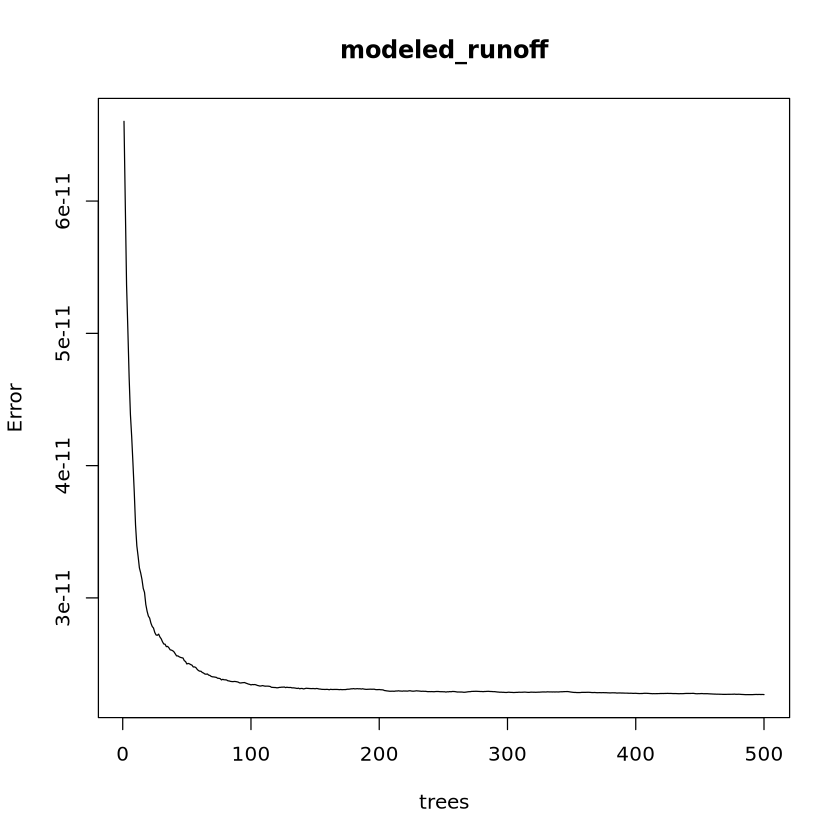

In [ ]:
plot(modeled_runoff)
print(modeled_runoff)

**Interpretation of Graph above:** The OOB error declines steeply up to roughly 50 trees and flattens into a stable plateau from about 100 trees onwards, so ntree = 100 was chosen as it already lies within the converged regime. Additional trees only increase computation time without reducing error.

,%IncMSE,IncNodePurity
PP0,81.14790,1.852033e-07
PP1,60.40491,1.776687e-07
PP2,49.32870,1.536295e-07
PP3,48.28435,9.752931e-08
PP4,45.59764,6.219907e-08
TT0,47.11734,6.801962e-08
TT1,39.14824,6.118702e-08
TT2,29.82834,3.988833e-08
TT3,37.16196,3.306180e-08
TT4,58.59221,4.977922e-08


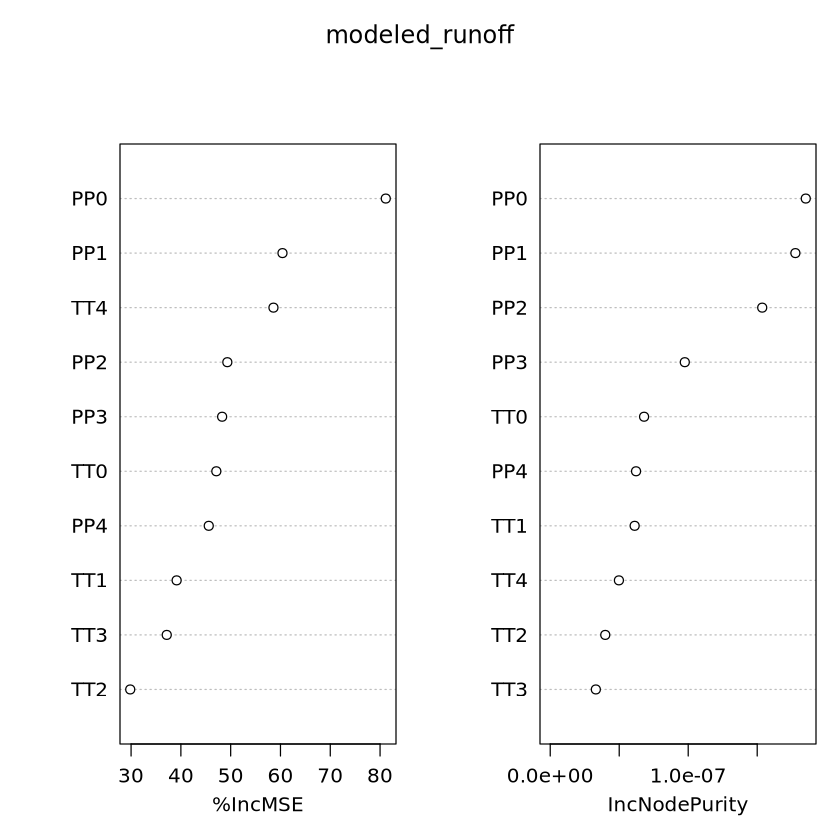

In [ ]:
# which predictors the model relies on most heavily (given in a table and also as a chart)
importance(modeled_runoff
varImpPlot(modeled_runoff)

In [ ]:
## create place holder for predictions
modeled_runoff.pred <- runoff.station$data
modeled_runoff.pred[] <- NA

## iterate over stations
for(st in colnames(precip.station$data)){
    ## prepare predictor matrix
    emb.predictors <- data.frame(
        embed.predictors(precip.station$data[,st],lambda=sel.lambda,var.name="PP"),
        embed.predictors(temp.station$data[,st],lambda=sel.lambda,var.name="TT")
    )
    ## do the prediction
    ## Note: the first (sel.lambda) values are left blank as a result of the embedding
    modeled_runoff.pred[-(1:sel.lambda),st] <- predict(modeled_runoff,newdata=emb.predictors)
}

In [ ]:
# Evaluation of the model
## overall performance
##

## romean squared error
mean((runoff.station$data - modeled_runoff.pred)^2,na.rm=TRUE)

## R-squared
cor(as.numeric(runoff.station$data),as.numeric(modeled_runoff.pred),use="complete.obs")^2

## performance at individual staitions

## mean squared error
sapply(colnames(runoff.station$data),function(i){
    mean((runoff.station$data[,i] - modeled_runoff.pred[,i])^2,na.rm=TRUE)
})

## R-squared
sapply(colnames(runoff.station$data),function(i){
    R2 <- cor(as.numeric(runoff.station$data[,i]),as.numeric(modeled_runoff.pred[,i]),
              use="complete.obs")^2
})

[1] 4.15852e-12

[1] 0.9807596

Station.1    Station.2    Station.3    Station.4    Station.5    Station.6 
3.066203e-12 2.110793e-12 2.225790e-14 6.411352e-13 1.231160e-12 3.433178e-12 
   Station.7    Station.8    Station.9   Station.10   Station.11   Station.12 
1.392553e-12 2.504532e-12 3.202488e-12 7.355577e-12 1.852248e-11 1.218152e-11 
  Station.13   Station.14   Station.15 
2.223164e-12 1.887716e-12 2.603045e-12

Station.1  Station.2  Station.3  Station.4  Station.5  Station.6  Station.7 
 0.9832094  0.6910466  0.6022119  0.8439627  0.3650922  0.9000115  0.8686347 
 Station.8  Station.9 Station.10 Station.11 Station.12 Station.13 Station.14 
 0.9653412  0.9670456  0.9888724  0.9694749  0.9495776  0.7475516  0.9302078 
Station.15 
 0.7301126

In [ ]:
#applying model to the full grid

# place holder for predicitons
runoff.grid.pred <- precip.grid$dat
runoff.grid.pred[] <- NA

for(ii in 1:dim(precip.grid$dat)[1]){
    for(jj in 1:dim(precip.grid$dat)[2]){
        emb.predictors <- data.frame(
            embed.predictors(precip.grid$dat[ii,jj,],lambda=sel.lambda,var.name="PP"),
            embed.predictors(temp.grid$dat[ii,jj,],lambda=sel.lambda,var.name="TT")
        )
        ## do the prediction
        ## Note: the first (sel.lambda) values are left blank as a result of the embedding
        runoff.grid.pred[ii,jj,-(1:sel.lambda)] <- predict(modeled_runoff,newdata=emb.predictors)
    }
}

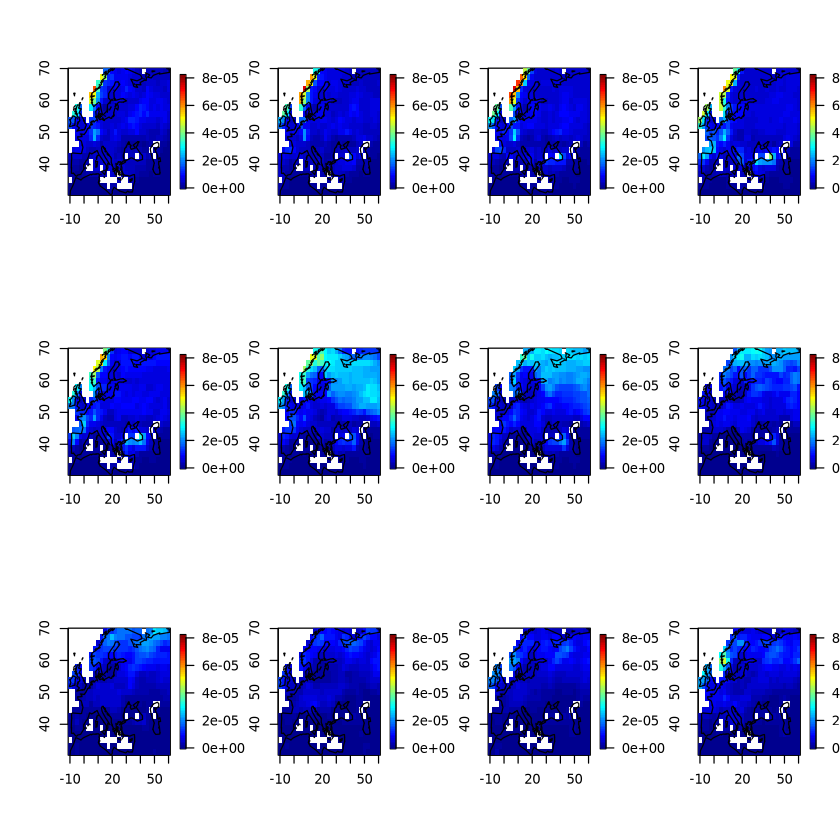

In [ ]:
# inspecting and saving the data
## plot some time slices (over 12 months)
runoff.range <- range(runoff.grid.pred,na.rm=TRUE)
par(mfrow=c(3,4))
for(i in 13:24){
    with(precip.grid,image.plot(x=coord$lon,y=coord$lat,
                                z=runoff.grid.pred[,,i],zlim=runoff.range,ann=FALSE))
    map("world",add=TRUE,interior=FALSE)
}

saveRDS(runoff.grid.pred,file="runoff_rf_group_12.rds")

To-do:
1. lamda wählen --> aktuell 4, durchprobieren welches lamda den kleinsten validen fehler wählen
2. mtry wählen
   --> Grid Search mit Validierung. So kann man wohl systematisch, ohne blind prüfen was das beste mtry und lamda ist. Wenn man blind rumprobiert und auf R2 optimiert dann kann es wohl zu overfitting kommen.
4. nodsize und maxnodes wohl nicht